# Supplementary Figure S5(D) — Cryo-EM pair score vs year, controlling for resolution

Year effect on pair score after removing resolution.

In [1]:
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
def _resolution(m):
    return (m.get("EM Diffraction Resolution (Å)") or m.get("Refinement_resolution")
            or m.get("EM Resolution (Å)"))


def _year(s):
    if not s:
        return None
    try:
        return datetime.fromisoformat(s).year
    except Exception:
        return None


def load_temporal_df():
    """Per-structure rows (>=5 pairs) with year, method, resolution, pairs_score."""
    sc = json.load(open(data_file("reference/scores/scores_all_uniques.json")))["scores"]
    vm = json.load(open(data_file("reference/metadata/metadata_cache.json")))["validation_metrics"]
    rows = []
    for pdb, info in sc.items():
        m = vm.get(pdb)
        if not isinstance(m, dict):
            continue
        year = _year(m.get("Deposition_Date"))
        method = m.get("Experimental_method")
        res = _resolution(m)
        if year is None or method not in ("X-ray", "EM") or res is None or res <= 0:
            continue
        rows.append({"pdb": pdb, "year": year, "method": method, "resolution": res,
                     "pairs_score": info["pairs_score"], "n_pairs": info.get("n_pairs", 0)})
    df = pd.DataFrame(rows)
    return df[df["n_pairs"] >= 5].reset_index(drop=True)


def yearly_agg(df):
    agg = (df.groupby(["method", "year"])
             .agg(resolution_mean=("resolution", "mean"), resolution_sem=("resolution", "sem"),
                  pairs_mean=("pairs_score", "mean"), pairs_sem=("pairs_score", "sem"),
                  n=("pdb", "count"))
             .reset_index().sort_values(["method", "year"]))
    for c in ("resolution_sem", "pairs_sem"):
        agg[c] = agg[c].fillna(0)
    return agg

In [3]:
df = load_temporal_df()
agg = yearly_agg(df)
em = df[df['method'] == 'EM'].dropna(subset=['year', 'resolution', 'pairs_score']).copy()

saved figures/figS5_D_partial_regression_year_given_resolution.png


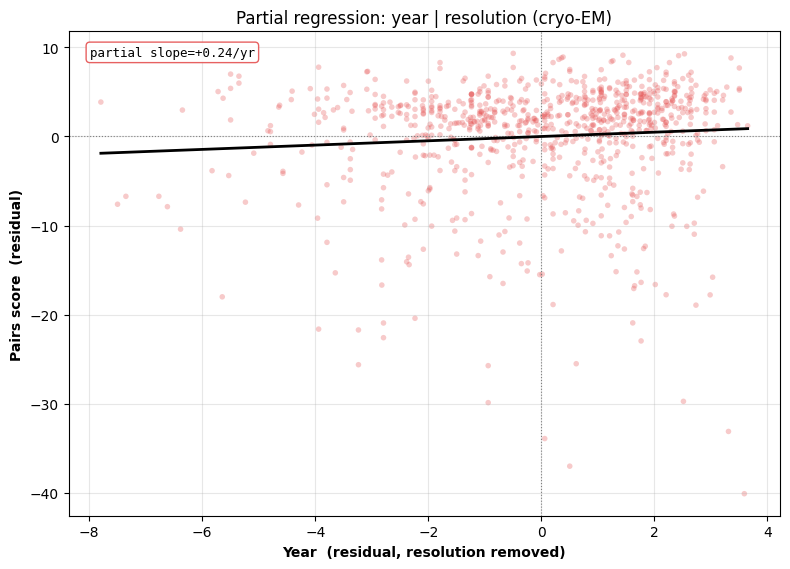

In [4]:
yr = em['year'].to_numpy(float); res = em['resolution'].to_numpy(float); ps = em['pairs_score'].to_numpy(float)
def _resid(v, ctrl):
    X = np.column_stack([np.ones(len(v)), ctrl - ctrl.mean()])
    beta, *_ = np.linalg.lstsq(X, v, rcond=None)
    return v - X @ beta
ry, rp = _resid(yr, res), _resid(ps, res)
s2, b2 = np.polyfit(ry, rp, 1)
fig, ax = plt.subplots(figsize=(8, 5.8))
ax.scatter(ry, rp, s=16, alpha=0.30, color='#E55050', edgecolor='none')
xx = np.linspace(ry.min(), ry.max(), 50); ax.plot(xx, s2*xx + b2, color='black', lw=2, zorder=5)
ax.axhline(0, color='gray', lw=0.8, ls=':'); ax.axvline(0, color='gray', lw=0.8, ls=':')
ax.text(0.03, 0.97, f'partial slope={s2:+.2f}/yr', transform=ax.transAxes,
        va='top', ha='left', family='monospace', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec='#E55050', alpha=0.9))
ax.set_xlabel('Year  (residual, resolution removed)', fontweight='bold')
ax.set_ylabel('Pairs score  (residual)', fontweight='bold')
ax.set_title('Partial regression: year | resolution (cryo-EM)'); ax.grid(alpha=0.3)
fig.tight_layout(); print('saved', savefig(fig, 'figS5_D_partial_regression_year_given_resolution.png')); plt.show()